In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import os
import numpy as np
import seaborn as sns
from scipy.stats import mannwhitneyu, false_discovery_control
import re
from itertools import combinations
from scipy.stats import pearsonr
from matplotlib import patches
import ast

ncpus = int(os.environ['NCPUS'])

# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

## Survival

In [2]:
better = pd.read_csv('/home/lnemati/pathway_crosstalk/results/survival/aggregate/better_pairs.csv')

In [3]:
# SAVE CROSSTALKDF WITH HALLAMRKS

dataframe = better.copy()

import re

# Split interactions into individual genes for each side
dataframe['interaction1'] = dataframe.interaction.apply(lambda x: re.split('&', x)[0].strip())
dataframe['interaction1'] = dataframe['interaction1'].apply(lambda x: re.split(r'[+_]', x))
dataframe['interaction2'] = dataframe.interaction.apply(lambda x: re.split('&', x)[1].strip())
dataframe['interaction2'] = dataframe['interaction2'].apply(lambda x: re.split(r'[+_]', x))

# Load geneset gene sets
def read_gmt(file_path):
    gene_sets = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                gene_sets[parts[0]] = set(parts[2:])
    return gene_sets

#genesets_path = '/home/lnemati/resources/msigdb_genesets/h.all.v2024.1.Hs.symbols.gmt'
genesets_path = '/home/lnemati/resources/MSigDB/c2.cp.reactome.v2026.1.Hs.symbols.gmt' # reactome canonical

genesets = read_gmt(genesets_path)

# Function to find matching geneset sets for a given gene list
def find_matching_genesets(gene_list, geneset_sets):
    return [name for name, genes in geneset_sets.items() if set(gene_list) & genes]

# Get genesets for each side of the interaction
dataframe['genesets1'] = dataframe['interaction1'].apply(lambda genes: find_matching_genesets(genes, genesets))
dataframe['genesets2'] = dataframe['interaction2'].apply(lambda genes: find_matching_genesets(genes, genesets))

# Convert to readable labels using the name map
#dataframe['genesets1'] = dataframe['genesets1'].apply(lambda hlist: [geneset_name_map[h] for h in hlist])
#dataframe['genesets2'] = dataframe['genesets2'].apply(lambda hlist: [geneset_name_map[h] for h in hlist])

dataframe = dataframe.query('tissue != "Pan_Cancer" and motif in ["3_clique", "4_clique"]')

#dataframe.to_csv('/home/lnemati/pathway_crosstalk/results/revision/survival/cliques_better_with_processes.csv')


# Define subset of genesets you want to consider (for example, top N or all unique found)
# For demonstration, use all unique genesets found across both sides:
all_genesets = sorted(set(sum(dataframe['genesets1'], [])) | set(sum(dataframe['genesets2'], [])))

# Initialize matrix: rows = interactions, columns = genesets
#heatmap_matrix = np.zeros((len(barplotdf), len(all_genesets)), dtype=int)

# Fill matrix with presence codes
#for i, row in enumerate(barplotdf.itertuples(index=False)):
#    genesets_1 = set(row.genesets1)
#    genesets_2 = set(row.genesets2)
#    for j, geneset in enumerate(all_genesets):
#        in_1 = geneset in genesets_1
#        in_2 = geneset in genesets_2
#        heatmap_matrix[i, j] = 1 * in_1 + 2 * in_2  # 0, 1, 2, or 3
#
#heatmap_df = pd.DataFrame(heatmap_matrix, index=barplotdf.interaction, columns=all_genesets)    
#heatmap_df = heatmap_df[::-1] # Invert to match order of the plot

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact

# Initialize storage for geneset analysis
bad_counts = []
good_counts = []
log_odds_ratios = []
p_values = []

# Total number of bad and good prognosis cases
bad_total = dataframe.query('hr > 1').shape[0]
good_total = dataframe.query('hr < 1').shape[0]

# Loop through each geneset
for hm in all_genesets:
    # a: geneset in poor prognosis
    a = dataframe.query('hr > 1').apply(lambda x: hm in x.genesets1 or hm in x.genesets2, axis=1).sum()
    b = bad_total - a  # geneset not in poor prognosis

    # c: geneset in good prognosis
    c = dataframe.query('hr < 1').apply(lambda x: hm in x.genesets1 or hm in x.genesets2, axis=1).sum()
    d = good_total - c  # geneset not in good prognosis

    # Store counts
    bad_counts.append(a)
    good_counts.append(c)

    # Fisher's exact test
    table = [[a, b], [c, d]]
    oddsratio, pvalue = fisher_exact(table)
    log_or = np.log2(oddsratio) if oddsratio > 0 else np.nan

    # Store test results
    log_odds_ratios.append(log_or)
    p_values.append(pvalue)

# Create the DataFrame
geneset_summary = pd.DataFrame({
    'geneset': all_genesets,
    'bad_prognosis_count': bad_counts,
    'good_prognosis_count': good_counts,
    'log_odds_ratio': log_odds_ratios,
    'p_value': p_values
})

# Also get probabilities not just counts
geneset_summary['bad_prognosis_prob'] = geneset_summary['bad_prognosis_count'] / bad_total
geneset_summary['good_prognosis_prob'] = geneset_summary['good_prognosis_count'] / good_total

# Optional: sort by significance or effect size
geneset_summary = geneset_summary.sort_values('p_value')

# Save the summary DataFrame
#geneset_summary.to_csv('/home/lnemati/pathway_crosstalk/results/revision/survival/genesets_survival.csv', index=False)

# Multiple hypothesis testing
geneset_summary['pval_adj'] = false_discovery_control(geneset_summary['p_value'])

geneset_summary['geneset'] = geneset_summary['geneset'].str.replace('REACTOME_', '').str.replace('_', ' ').str.title()

#for str1, str2 in replace.items():
#    geneset_summary['geneset'] = geneset_summary['geneset'].str.replace(str1, str2)

#good_df = geneset_summary.query('log_odds_ratio < 0').sort_values(by='good_prognosis_prob', ascending=False)
#bad_df = geneset_summary.query('log_odds_ratio > 0').sort_values(by='bad_prognosis_prob', ascending=False)

good_df = geneset_summary.query('pval_adj < 0.05 and log_odds_ratio < 0').sort_values(by='good_prognosis_prob', ascending=False)
bad_df = geneset_summary.query('pval_adj < 0.05 and log_odds_ratio > 0').sort_values(by='bad_prognosis_prob', ascending=False)

replace = {
    'Turbulent Oscillatory Disturbed Flow Shear Stress Activates Signaling By Piezo1 And Integrins In Endothelial Cells': 'Turbulent [...] Signaling By Piezo1 And Integrins In Endothelial Cells',
    'Nef Mediates Down Modulation Of Cell Surface Receptors By Recruiting Them To Clathrin Adapters': 'Nef Mediates Down Modulation Of Cell Surface Receptors [...] Clathrin Adapters'
}

good_df['geneset'] = good_df['geneset'].replace(replace)
bad_df['geneset'] = bad_df['geneset'].replace(replace)


In [5]:
good_df['log_odds_ratio'].median()

np.float64(-0.8401203235341643)

In [6]:
bad_df['log_odds_ratio'].median()

np.float64(3.7214281765460697)

In [7]:
bad_df

,geneset,bad_prognosis_count,good_prognosis_count,log_odds_ratio,p_value,bad_prognosis_prob,good_prognosis_prob,pval_adj
81,Cytokine Signaling In Immune System,1814,1045,1.154753,2.826927e-11,0.929303,0.855155,1.670457e-10
425,Signaling By Interleukins,1669,923,0.933925,3.338203e-12,0.855020,0.755319,1.995248e-11
3,Adaptive Immune System,1667,941,0.804596,3.038630e-09,0.853996,0.770049,1.564443e-08
193,Infectious Disease,1516,836,0.682968,1.092066e-08,0.776639,0.684124,5.357304e-08
515,Viral Infection Pathways,1487,811,0.696539,2.412185e-09,0.761783,0.663666,1.254336e-08
...,...,...,...,...,...,...,...,...
138,Epigenetic Regulation Of Gene Expression,12,1,2.916969,2.186584e-02,0.006148,0.000818,4.164922e-02
139,Epigenetic Regulation Of Gene Expression By Ml...,12,1,2.916969,2.186584e-02,0.006148,0.000818,4.164922e-02
289,Nrcam Interactions,11,0,inf,9.027379e-03,0.005635,0.000000,1.908226e-02
119,Dissolution Of Fibrin Clot,11,0,inf,9.027379e-03,0.005635,0.000000,1.908226e-02


In [8]:
bad_df[bad_df.geneset.str.lower().str.contains('veg')]

,geneset,bad_prognosis_count,good_prognosis_count,log_odds_ratio,p_value,bad_prognosis_prob,good_prognosis_prob,pval_adj
453,Signaling By Vegf,75,3,4.021126,4.997629e-13,0.038422,0.002455,3.131045e-12
512,Vegfr2 Mediated Cell Proliferation,16,2,2.333802,1.507059e-02,0.008197,0.001637,3.073217e-02
513,Vegf Ligand Receptor Interactions,16,2,2.333802,1.507059e-02,0.008197,0.001637,3.073217e-02


In [9]:
bad_df.geneset.values

array(['Cytokine Signaling In Immune System', 'Signaling By Interleukins',
       'Adaptive Immune System', 'Infectious Disease',
       'Viral Infection Pathways',
       'Immunoregulatory Interactions Between A Lymphoid And A Non Lymphoid Cell',
       'Interleukin 4 And Interleukin 13 Signaling',
       'Sars Cov Infections', 'Hemostasis',
       'Cell Surface Interactions At The Vascular Wall',
       'Extracellular Matrix Organization',
       'Integrin Cell Surface Interactions',
       'Signaling By Receptor Tyrosine Kinases',
       'Potential Therapeutics For Sars', 'Ecm Proteoglycans',
       'Rho Gtpase Cycle',
       'Signaling By Rho Gtpases Miro Gtpases And Rhobtb3',
       'Cellular Responses To Stimuli', 'Nervous System Development',
       'Non Integrin Membrane Ecm Interactions',
       'G Alpha S Signalling Events',
       'Cellular Responses To Mechanical Stimuli', 'Basigin Interactions',
       'Syndecan Interactions', 'Signaling By Tgfb Family Members',
       'Ot

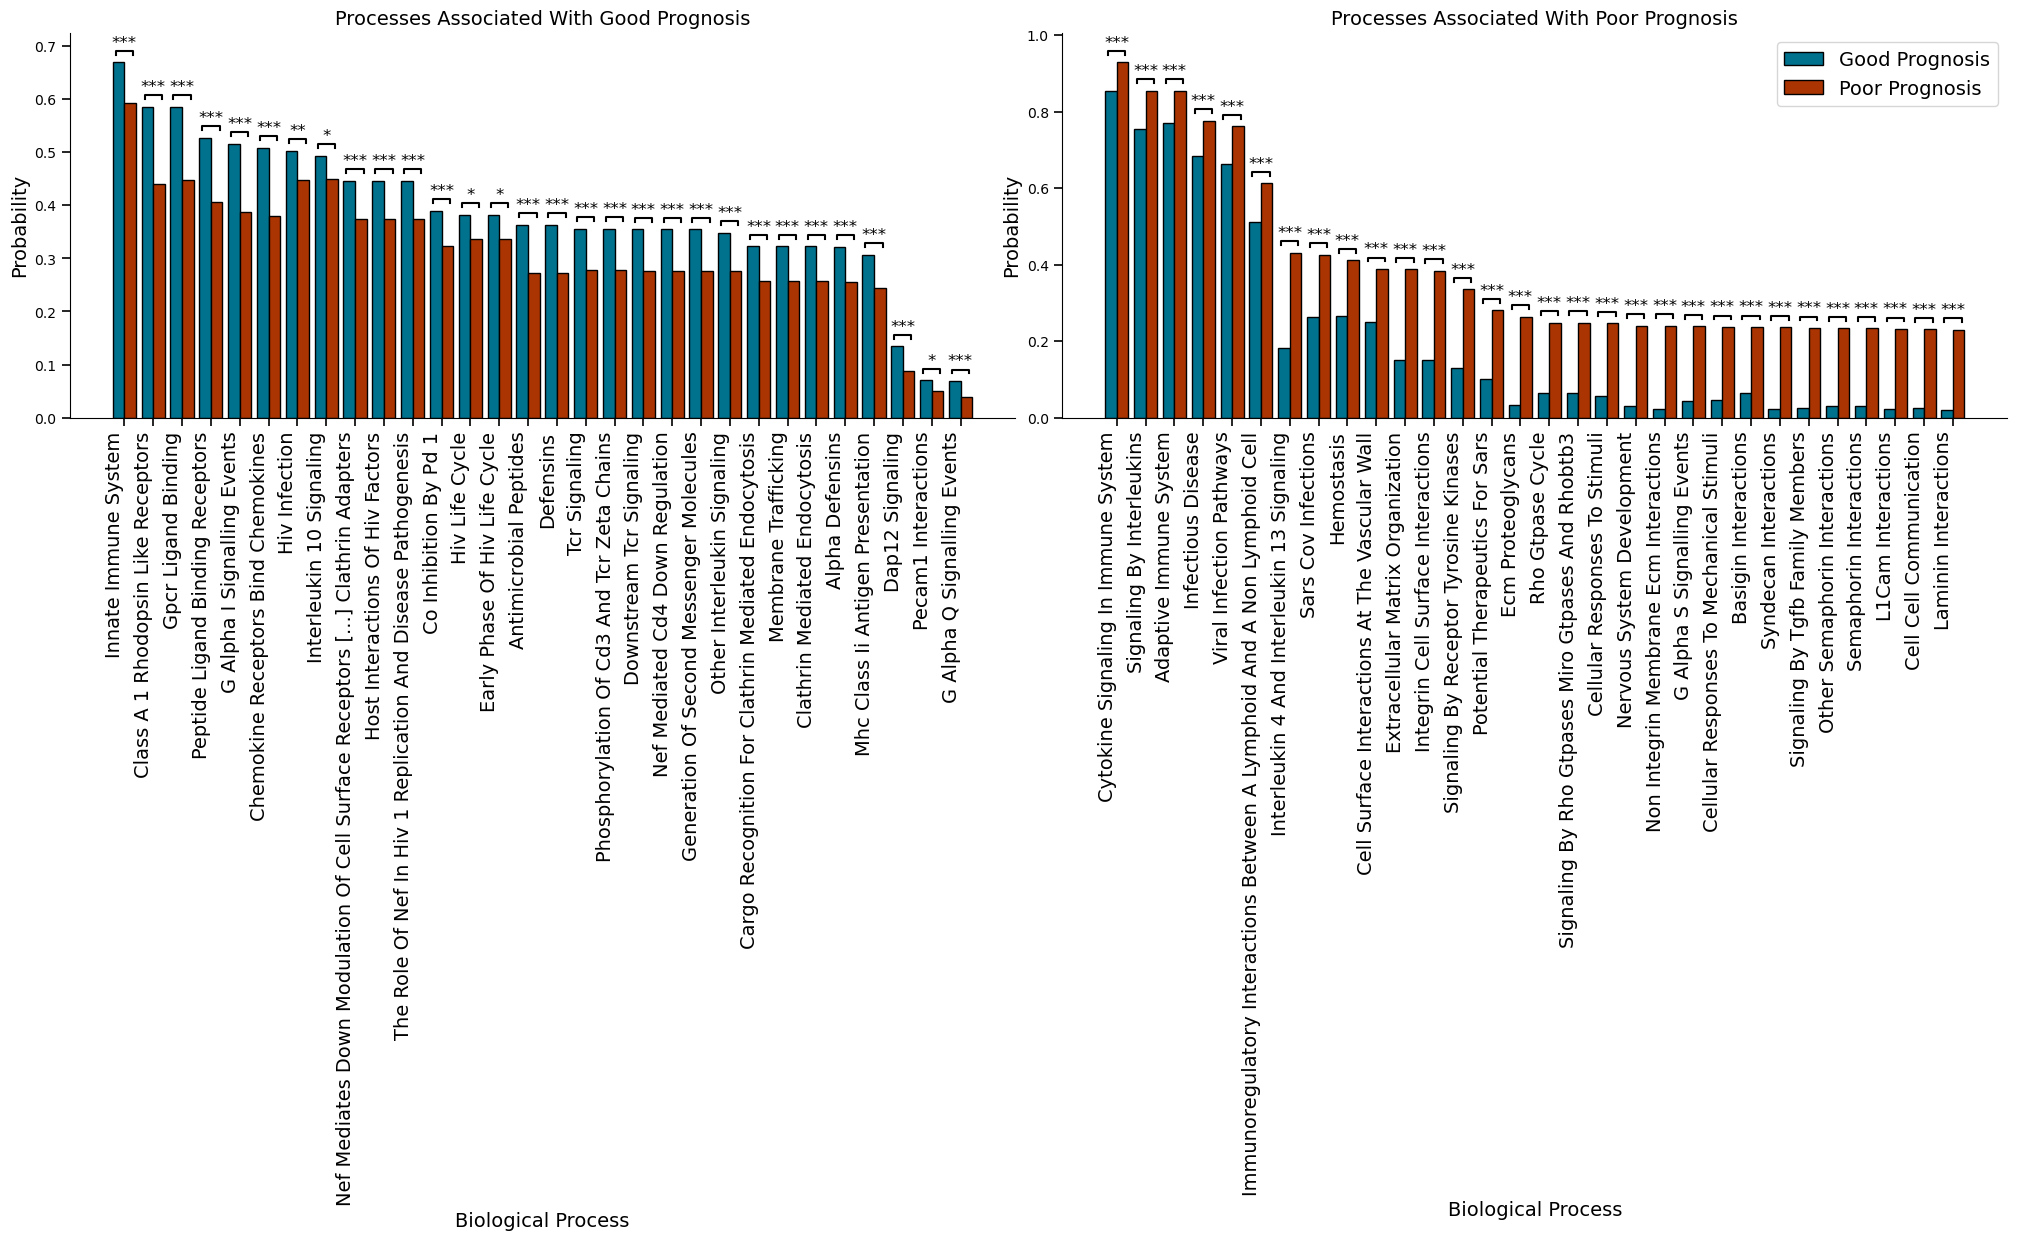

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Constants
per_bar_width = 0.6  # width in inches per bar, tweak as needed
height = 6           # fixed figure height
fs = 14
smallfs = 11

# Function to plot one panel with vertical bars
def plot_panel(df, ax, title, color1, color2,):
    genesets = df['geneset']
    x_pos = np.arange(len(df))

    ax.bar(x_pos - 0.2, df['good_prognosis_prob'], width=0.4, color=color1, edgecolor='black', label='Good Prognosis')
    ax.bar(x_pos + 0.2, df['bad_prognosis_prob'], width=0.4, color=color2, edgecolor='black', label='Poor Prognosis')

    for i, row in df.iterrows():
        total_height = ax.get_ylim()[1] - ax.get_ylim()[0]
        x = x_pos[df.index.get_loc(i)]
        pval = row['pval_adj']
        stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        if stars:
            max_prob = max(row['good_prognosis_prob'], row['bad_prognosis_prob'])
            ypos = max_prob + 0.02 * total_height
            h = 0.01 * total_height
            w = 0.3
            ax.plot([x - w, x - w, x + w, x + w], [ypos, ypos + h, ypos + h, ypos], color='black', linewidth=1.5)
            ax.text(x, max_prob + 4*h, stars, ha='center', fontsize=12)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(genesets, rotation=90, ha='right', fontsize=fs)
    ax.set_ylabel('Probability', fontsize=fs)
    ax.set_xlabel('Biological Process', fontsize=fs)
    ax.set_title(title, fontsize=fs)

    # Imposta che i tick siano mostrati
    ax.tick_params(
        axis='both',
        which='both',
        direction='out',
        length=6,
        width=1.2,
        color='black'
    )
    ax.xaxis.set_ticks_position('bottom')  # obbliga i tick sull’asse x
    ax.yaxis.set_ticks_position('left')    # obbliga i tick sull’asse y

    # Hide top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add legend
    ax.legend(fontsize=fs, loc='upper right')

# Calculate subplot widths
top_N = 30
total_width = 2*50

#good_width = max(len(good_df) * per_bar_width, 2)  # min width 2 inches for readability
#bad_width = max(len(bad_df) * per_bar_width, 2)
#total_width = good_width + bad_width

fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(25, 5),
    #gridspec_kw={'width_ratios': [good_width, bad_width]},
    sharey=False
)

plt.subplots_adjust(wspace=0.05)

# Plot both panels
plot_panel(good_df.head(top_N), ax1, 'Processes Associated With Good Prognosis', ncolor, tcolor)
plot_panel(bad_df.head(top_N), ax2, 'Processes Associated With Poor Prognosis', ncolor, tcolor)

# Remove legend from ax1
ax1.legend_.remove()

# Save the figure
#plt.savefig(f'/home/lnemati/pathway_crosstalk/results/revision/images/survival_reactome_prognosis_top{top_N}.pdf', bbox_inches='tight', dpi=300)
#plt.savefig(f'/home/lnemati/pathway_crosstalk/results/revision/images/survival_reactome_prognosis_top{top_N}.png', bbox_inches='tight', dpi=300)

plt.show()


## Immunotherapy

In [11]:
parentdir = '/home/lnemati/pathway_crosstalk/results/immunotherapy/individual_interactions_and_motifs'

dfs = []

for tissue in os.listdir(parentdir):
    #if tissue in ['full_dataset']: # add back lymph and ureter when they finish running
    #    continue
    path = os.path.join(parentdir, tissue, 'aggregated', 'aggregated.csv')
    tissuedf = pd.read_csv(os.path.join(path))
    tissuedf = tissuedf.rename(columns={'Unnamed: 0': 'interaction'})
    #tissuedf['motif'] = tissuedf['motif'].replace({'3_clique': 'cliques', '4_clique': 'cliques'})

    dfs.append(tissuedf)
        
crosstalkdf = pd.concat(dfs, ignore_index=True)
#crosstalkdf = crosstalkdf.dropna()

crosstalkdf = crosstalkdf.sort_values(by='auroc')[::-1]
crosstalkdf = crosstalkdf.query('motif in ["3_clique", "4_clique"]')
#crosstalkdf = crosstalkdf.query('tissue != "full_dataset"')

better = crosstalkdf.query('auroc > auroc1 and auroc > auroc2')
better = better.query('auprc > auprc1 and auprc > auprc2')
better_idx = better.index

crosstalkdf['better'] = False
crosstalkdf.loc[better.index, 'better'] = True

crosstalkdf['interaction'] = crosstalkdf.interaction.str.replace('_', ' - ').str.replace('+', ' - ').str.replace('&', ' & ')

# Split interactions into individual genes for each side
crosstalkdf['interaction1'] = crosstalkdf.interaction.apply(lambda x: re.split('&', x)[0].strip().split(' - '))
crosstalkdf['interaction2'] = crosstalkdf.interaction.apply(lambda x: re.split('&', x)[1].strip().split(' - '))

# Load geneset gene sets
def read_gmt(file_path):
    gene_sets = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                gene_sets[parts[0]] = set(parts[2:])
    return gene_sets

#genesets_path = '/home/lnemati/resources/gene_ontology/GOBP.gmt' # go biological process
genesets_path = '/home/lnemati/resources/MSigDB/c2.cp.reactome.v2026.1.Hs.symbols.gmt' # reactome canonical

genesets = read_gmt(genesets_path)

from collections import defaultdict

def build_gene_to_genesets(genesets):
    gene_to_sets = defaultdict(set)
    for gs_name, genes in genesets.items():
        for g in genes:
            gene_to_sets[g].add(gs_name)
    return gene_to_sets


def find_matching_genesets_fast(gene_list, gene_to_sets):
    result = set()
    for g in gene_list:
        if g in gene_to_sets:
            result.update(gene_to_sets[g])
    return list(result)

gene_to_sets = build_gene_to_genesets(genesets)

crosstalkdf['genesets1'] = crosstalkdf['interaction1'].apply(
    lambda genes: find_matching_genesets_fast(genes, gene_to_sets)
)

crosstalkdf['genesets2'] = crosstalkdf['interaction2'].apply(
    lambda genes: find_matching_genesets_fast(genes, gene_to_sets)
)

all_genesets = list(
    set().union(*crosstalkdf['genesets1'], *crosstalkdf['genesets2'])
)

In [12]:
import numpy as np
import pandas as pd
from multiprocessing import Pool, cpu_count
from tqdm.auto import tqdm

# ------------------------------------------------------------------
# 1.  Build once: boolean membership matrix  (rows × genesets)
# ------------------------------------------------------------------
def _build_membership_matrix(crosstalkdf, all_genesets):
    df = crosstalkdf.reset_index(drop=True)
    h_to_col = {h: j for j, h in enumerate(all_genesets)}

    M = np.zeros((len(df), len(all_genesets)), dtype=bool)
    for i, (h1, h2) in enumerate(zip(df['genesets1'], df['genesets2'])):
        for h in set(h1) | set(h2):
            j = h_to_col.get(h)
            if j is not None:
                M[i, j] = True
    return M, df


# ------------------------------------------------------------------
# 2.  Fast geneset analysis
# ------------------------------------------------------------------
def _summarise(M, better_mask, all_genesets):
    idx = better_mask.values if isinstance(better_mask, pd.Series) else better_mask
    sel = M[idx]
    counts = sel.sum(axis=0)
    probs = counts / idx.sum()
    return pd.DataFrame({
        'geneset': all_genesets,
        'counts': counts,
        'probs': probs,
    })


# ------------------------------------------------------------------
# 3.  Globals for multiprocessing workers
# ------------------------------------------------------------------
_M = None
_better = None
_all_genesets = None
_seed_seq = None


def _init_worker(M, better, all_genesets, seed_seq):
    global _M, _better, _all_genesets, _seed_seq
    _M = M
    _better = better
    _all_genesets = all_genesets
    _seed_seq = seed_seq


def _one_perm(i):
    # independent RNG per task (reproducible if seed_seq given)
    rng = np.random.default_rng(_seed_seq.spawn(1)[0] if _seed_seq else None)
    shuffled = rng.permutation(_better)
    return _summarise(_M, shuffled, _all_genesets)


# ------------------------------------------------------------------
# 4.  Driver with multiprocessing + tqdm
# ------------------------------------------------------------------
def analyze_genesets_fast_mp(
    crosstalkdf,
    all_genesets,
    n_perms=1000,
    n_jobs=None,
    random_state=None
):
    if n_jobs is None:
        n_jobs = cpu_count()

    # Build once
    M, df = _build_membership_matrix(crosstalkdf, all_genesets)
    better = df['better'].to_numpy()

    # Real values
    real_summary = _summarise(M, better, all_genesets)
    real_summary = real_summary.sort_values(by='counts', ascending=False)

    # Seed handling
    seed_seq = np.random.SeedSequence(random_state) if random_state is not None else None

    # Parallel permutations
    with Pool(
        processes=n_jobs,
        initializer=_init_worker,
        initargs=(M, better, all_genesets, seed_seq)
    ) as pool:

        results = list(
            tqdm(
                pool.imap_unordered(_one_perm, range(n_perms)),
                total=n_perms,
                desc="Permutations"
            )
        )

    permuted_summary = pd.concat(results, ignore_index=True)

    return real_summary, permuted_summary


# ------------------------------------------------------------------
# 5.  Run
# ------------------------------------------------------------------
real_values, permuted_values = analyze_genesets_fast_mp(
    crosstalkdf,
    all_genesets,
    #n_perms=5000,
    n_perms=1000,
    n_jobs=ncpus,          # use all cores
    random_state=42       # optional reproducibility
)

real_values = real_values.set_index('geneset')

Permutations:   0%|          | 0/1000 [00:00<?, ?it/s]

In [13]:
real_values.sort_values(by='probs')[::-1]

,counts,probs
geneset,,
REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM,9513,0.903076
REACTOME_SIGNALING_BY_INTERLEUKINS,8835,0.838713
REACTOME_ADAPTIVE_IMMUNE_SYSTEM,8505,0.807386
REACTOME_INFECTIOUS_DISEASE,7854,0.745586
REACTOME_VIRAL_INFECTION_PATHWAYS,7585,0.720049
...,...,...
REACTOME_TRANSCRIPTIONAL_REGULATION_BY_TP53,3,0.000285
REACTOME_INTRA_GOLGI_AND_RETROGRADE_GOLGI_TO_ER_TRAFFIC,3,0.000285
REACTOME_RIPK1_MEDIATED_REGULATED_NECROSIS,3,0.000285


In [14]:
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd

def get_p_values(real_values, permuted_values):

    genesets = real_values.index

    # group permuted counts once (NO pivot)
    grouped = permuted_values.groupby('geneset')['counts']

    pvals = {}

    for gs in genesets:
        real = real_values.loc[gs, 'counts']

        perm = grouped.get_group(gs).to_numpy()

        mean = perm.mean()

        real_dev = abs(real - mean)
        perm_dev = np.abs(perm - mean)

        pvals[gs] = (perm_dev >= real_dev).mean()

    return pd.Series(pvals, name="p_value")

p_values = get_p_values(real_values, permuted_values)
pvals_adj = pd.Series(false_discovery_control(p_values), index=p_values.index)

In [15]:
means = permuted_values.groupby('geneset')['counts'].mean()
stds = permuted_values.groupby('geneset')['counts'].std()

# get z-scores
gs_z_scores = (real_values['counts'] - means) / stds
gs_z_scores = gs_z_scores.sort_values(ascending=False)
pvals_adj = pvals_adj.loc[gs_z_scores.index]    

# subset to only significant genesets
gs_z_scores = gs_z_scores[pvals_adj < 0.05]
pvals_adj = pvals_adj[pvals_adj < 0.05]

In [16]:
gs_z_scores[gs_z_scores < 0]

geneset
REACTOME_POST_TRANSLATIONAL_MODIFICATION_SYNTHESIS_OF_GPI_ANCHORED_PROTEINS                          -2.119027
REACTOME_DENGUE_VIRUS_HOST_INTERACTIONS                                                              -2.245572
REACTOME_SLC_MEDIATED_TRANSMEMBRANE_TRANSPORT                                                        -2.325790
REACTOME_TRANSPORT_OF_VITAMINS_NUCLEOSIDES_AND_RELATED_MOLECULES                                     -2.325790
REACTOME_TRANSPORT_OF_NUCLEOSIDES_AND_FREE_PURINE_AND_PYRIMIDINE_BASES_ACROSS_THE_PLASMA_MEMBRANE    -2.325790
                                                                                                       ...    
REACTOME_DEVELOPMENTAL_LINEAGE_OF_MAMMARY_GLAND_LUMINAL_EPITHELIAL_CELLS                            -11.211732
REACTOME_SYNDECAN_INTERACTIONS                                                                      -11.239711
REACTOME_SIGNALING_BY_TGFB_FAMILY_MEMBERS                                                           -11.

In [17]:
gs_z_scores[gs_z_scores > 0].index

Index(['REACTOME_HIV_INFECTION', 'REACTOME_HIV_LIFE_CYCLE',
       'REACTOME_EARLY_PHASE_OF_HIV_LIFE_CYCLE',
       'REACTOME_THE_ROLE_OF_NEF_IN_HIV_1_REPLICATION_AND_DISEASE_PATHOGENESIS',
       'REACTOME_NEF_MEDIATES_DOWN_MODULATION_OF_CELL_SURFACE_RECEPTORS_BY_RECRUITING_THEM_TO_CLATHRIN_ADAPTERS',
       'REACTOME_HOST_INTERACTIONS_OF_HIV_FACTORS',
       'REACTOME_NEF_MEDIATED_CD4_DOWN_REGULATION',
       'REACTOME_DOWNSTREAM_TCR_SIGNALING',
       'REACTOME_GENERATION_OF_SECOND_MESSENGER_MOLECULES',
       'REACTOME_ALPHA_DEFENSINS', 'REACTOME_TCR_SIGNALING',
       'REACTOME_PHOSPHORYLATION_OF_CD3_AND_TCR_ZETA_CHAINS',
       'REACTOME_OTHER_INTERLEUKIN_SIGNALING', 'REACTOME_MEMBRANE_TRAFFICKING',
       'REACTOME_CLATHRIN_MEDIATED_ENDOCYTOSIS',
       'REACTOME_CARGO_RECOGNITION_FOR_CLATHRIN_MEDIATED_ENDOCYTOSIS',
       'REACTOME_CO_INHIBITION_BY_PD_1', 'REACTOME_DEFENSINS',
       'REACTOME_REGULATION_OF_T_CELL_ACTIVATION_BY_CD28_FAMILY',
       'REACTOME_ANTIMICROBIAL_PEPTI

In [18]:
gs_z_scores[gs_z_scores < 0].tail(100).index

Index(['REACTOME_DISEASES_OF_METABOLISM', 'REACTOME_SIGNALING_BY_GPCR',
       'REACTOME_DAP12_SIGNALING',
       'REACTOME_STAT3_NUCLEAR_EVENTS_DOWNSTREAM_OF_ALK_SIGNALING',
       'REACTOME_HEMOSTASIS', 'REACTOME_SMOOTH_MUSCLE_CONTRACTION',
       'REACTOME_MUSCLE_CONTRACTION', 'REACTOME_SIGNALING_BY_ALK',
       'REACTOME_CLASS_B_2_SECRETIN_FAMILY_RECEPTORS',
       'REACTOME_MITF_M_REGULATED_MELANOCYTE_DEVELOPMENT',
       'REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION',
       'REACTOME_REGULATION_OF_MITF_M_DEPENDENT_GENES_INVOLVED_IN_EXTRACELLULAR_MATRIX_FOCAL_ADHESION_AND_EPITHELIAL_TO_MESENCHYMAL_TRANSITION',
       'REACTOME_INTEGRIN_CELL_SURFACE_INTERACTIONS',
       'REACTOME_CROSS_PRESENTATION_OF_PARTICULATE_EXOGENOUS_ANTIGENS_PHAGOSOMES',
       'REACTOME_SIGNALING_BY_PDGF', 'REACTOME_SIGNALING_BY_VEGF',
       'REACTOME_INTERLEUKIN_4_AND_INTERLEUKIN_13_SIGNALING',
       'REACTOME_BINDING_AND_UPTAKE_OF_LIGANDS_BY_SCAVENGER_RECEPTORS',
       'REACTOME_IMMUNOREGULATORY_INTERAC

In [19]:
top_n = 30
gs_z_scores_top = gs_z_scores.loc[gs_z_scores[:top_n].index.union(gs_z_scores[-top_n:].index)].sort_values()
pvals_adj_top = pvals_adj.loc[gs_z_scores_top.index]

replace = {
    'REACTOME_TURBULENT_OSCILLATORY_DISTURBED_FLOW_SHEAR_STRESS_ACTIVATES_SIGNALING_BY_PIEZO1_AND_INTEGRINS_IN_ENDOTHELIAL_CELLS': 'REACTOME_TURBULENT_[...]_SIGNALING_BY_PIEZO1_AND_INTEGRINS_IN_ENDOTHELIAL_CELLS',
    'REACTOME_NEF MEDIATES DOWN MODULATION OF CELL SURFACE RECEPTORS BY RECRUITING THEM TO CLATHRIN ADAPTERS': 'NEF MEDIATES DOWN MODULATION OF CELL SURFACE RECEPTORS [...] CLATHRIN ADAPTERS',

}

gs_z_scores_top = gs_z_scores_top.rename(index=replace)
pvals_adj_top = pvals_adj_top.rename(index=replace)


/var/tmp/pbs.435159.pbs01/ipykernel_25313/1859815587.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(


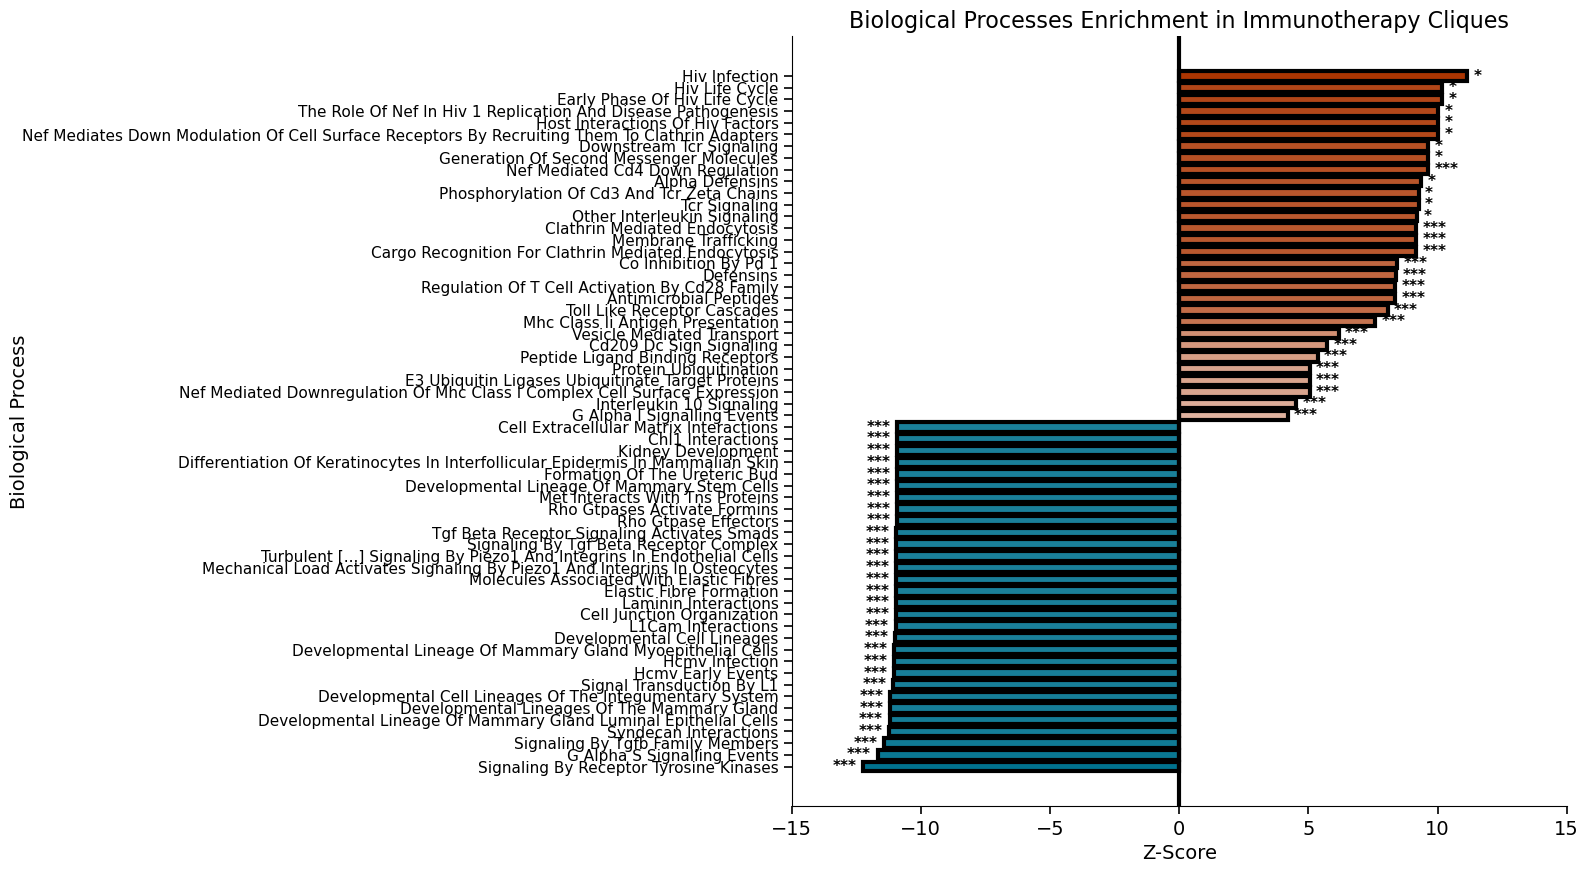

In [20]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- STYLE (same as your figure) ---
fs = 14
smallfs = 11

# --- COLORS ---
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom_gradient', [ncolor, 'white', tcolor]
)
norm = mcolors.TwoSlopeNorm(
    vmin=gs_z_scores_top.min(),
    vcenter=0,
    vmax=gs_z_scores_top.max()
)
colors = cmap(norm(gs_z_scores_top))

# --- FIGURE ---
fig, ax = plt.subplots(figsize=(10, 10))# dpi=300)

# --- BARS ---
bars = ax.barh(
    gs_z_scores_top.index.str.replace('REACTOME_', '').str.replace('_', ' ').str.title(),
    gs_z_scores_top,
    color=colors,
    edgecolor='k',
    linewidth=3,
)

# --- ZERO LINE ---
ylim = ax.get_ylim()
ax.vlines(0, ylim[0], ylim[1], color='k', linestyle='-', linewidth=3)
ax.set_ylim(ylim[0], ylim[1])

# --- TITLES / LABELS ---
ax.set_title(
    "Biological Processes Enrichment in Immunotherapy Cliques",
    fontsize=16
)
ax.set_ylabel("Biological Process", fontsize=fs, labelpad=-5)
ax.set_xlabel("Z-Score", fontsize=fs)

# --- SIGNIFICANCE ---
sig_levels = {0.001: '***', 0.01: '**', 0.05: '*'}

for bar, z_score, p_val in zip(bars, gs_z_scores_top, pvals_adj):
    width = bar.get_width()
    sig_symbol = next(
        (symbol for threshold, symbol in sig_levels.items() if p_val <= threshold),
        None
    )
    
    if sig_symbol:
        text_x = width + 0.25 if z_score > 0 else width - 0.25
        
        ax.text(
            text_x,
            bar.get_y() + bar.get_height() / 2,
            sig_symbol,
            va='center',
            ha='left' if z_score > 0 else 'right',
            fontsize=smallfs,   # <-- matches Panel F
            fontweight='bold'
        )

# --- AXIS STYLE (GLOBAL STYLE BLOCK FROM YOUR FIGURE) ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.tick_params(
    axis='both',
    which='both',
    labelsize=fs,
    direction='out',
    length=6,
    width=1.2,
    colors='black'
)

# --- TICK LABELS ---
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    ha='right',
    fontsize=smallfs   # <-- key Panel F detail
)


# --- LIMITS ---
ax.set_xlim(-15, 15)

#plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/immuntherapy_enrichment_reactome_canonical.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/immuntherapy_enrichment_reactome_canonical.png', bbox_inches='tight', dpi=300)

plt.show()

In [ ]:
# Plot 1

import matplotlib.pyplot as plt
import numpy as np

# Constants
per_bar_width = 0.6  # width in inches per bar, tweak as needed
height = 6           # fixed figure height
fs = 14
smallfs = 11

# Function to plot one panel with vertical bars
def plot_panel(df, ax, title, color1, color2,):
    genesets = df['geneset']
    x_pos = np.arange(len(df))

    ax.bar(x_pos - 0.2, df['good_prognosis_prob'], width=0.4, color=color1, edgecolor='black', label='Good Prognosis')
    ax.bar(x_pos + 0.2, df['bad_prognosis_prob'], width=0.4, color=color2, edgecolor='black', label='Poor Prognosis')

    for i, row in df.iterrows():
        total_height = ax.get_ylim()[1] - ax.get_ylim()[0]
        x = x_pos[df.index.get_loc(i)]
        pval = row['pval_adj']
        stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        if stars:
            max_prob = max(row['good_prognosis_prob'], row['bad_prognosis_prob'])
            ypos = max_prob + 0.02 * total_height
            h = 0.01 * total_height
            w = 0.3
            ax.plot([x - w, x - w, x + w, x + w], [ypos, ypos + h, ypos + h, ypos], color='black', linewidth=1.5)
            ax.text(x, max_prob + 4*h, stars, ha='center', fontsize=12)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(genesets, rotation=90, ha='right', fontsize=fs)
    ax.set_ylabel('Probability', fontsize=fs)
    ax.set_xlabel('Biological Process', fontsize=fs)
    ax.set_title(title, fontsize=fs)

    # Imposta che i tick siano mostrati
    ax.tick_params(
        axis='both',
        which='both',
        direction='out',
        length=6,
        width=1.2,
        color='black'
    )
    ax.xaxis.set_ticks_position('bottom')  # obbliga i tick sull’asse x
    ax.yaxis.set_ticks_position('left')    # obbliga i tick sull’asse y

    # Hide top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add legend
    ax.legend(fontsize=fs, loc='upper right')

# Calculate subplot widths
top_N = 30
total_width = 2*50

#good_width = max(len(good_df) * per_bar_width, 2)  # min width 2 inches for readability
#bad_width = max(len(bad_df) * per_bar_width, 2)
#total_width = good_width + bad_width

fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(25, 5),
    #gridspec_kw={'width_ratios': [good_width, bad_width]},
    sharey=False
)

plt.subplots_adjust(wspace=0.05)

# Plot both panels
plot_panel(good_df.head(top_N), ax1, 'Processes Associated With Good Prognosis', ncolor, tcolor)
plot_panel(bad_df.head(top_N), ax2, 'Processes Associated With Poor Prognosis', ncolor, tcolor)

# Remove legend from ax1
ax1.legend_.remove()

# Save the figure
#plt.savefig(f'/home/lnemati/pathway_crosstalk/results/revision/images/survival_reactome_prognosis_top{top_N}.pdf', bbox_inches='tight', dpi=300)
#plt.savefig(f'/home/lnemati/pathway_crosstalk/results/revision/images/survival_reactome_prognosis_top{top_N}.png', bbox_inches='tight', dpi=300)

plt.show()



# Plot 2

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# --- STYLE (same as your figure) ---
fs = 14
smallfs = 11

# --- COLORS ---
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom_gradient', [ncolor, 'white', tcolor]
)
norm = mcolors.TwoSlopeNorm(
    vmin=gs_z_scores_top.min(),
    vcenter=0,
    vmax=gs_z_scores_top.max()
)
colors = cmap(norm(gs_z_scores_top))

# --- FIGURE ---
fig, ax = plt.subplots(figsize=(10, 10))# dpi=300)

# --- BARS ---
bars = ax.barh(
    gs_z_scores_top.index.str.replace('REACTOME_', '').str.replace('_', ' ').str.title(),
    gs_z_scores_top,
    color=colors,
    edgecolor='k',
    linewidth=3,
)

# --- ZERO LINE ---
ylim = ax.get_ylim()
ax.vlines(0, ylim[0], ylim[1], color='k', linestyle='-', linewidth=3)
ax.set_ylim(ylim[0], ylim[1])

# --- TITLES / LABELS ---
ax.set_title(
    "Biological Processes Enrichment in Immunotherapy Cliques",
    fontsize=16
)
ax.set_ylabel("Biological Process", fontsize=fs, labelpad=-5)
ax.set_xlabel("Z-Score", fontsize=fs)

# --- SIGNIFICANCE ---
sig_levels = {0.001: '***', 0.01: '**', 0.05: '*'}

for bar, z_score, p_val in zip(bars, gs_z_scores_top, pvals_adj):
    width = bar.get_width()
    sig_symbol = next(
        (symbol for threshold, symbol in sig_levels.items() if p_val <= threshold),
        None
    )
    
    if sig_symbol:
        text_x = width + 0.25 if z_score > 0 else width - 0.25
        
        ax.text(
            text_x,
            bar.get_y() + bar.get_height() / 2,
            sig_symbol,
            va='center',
            ha='left' if z_score > 0 else 'right',
            fontsize=smallfs,   # <-- matches Panel F
            fontweight='bold'
        )

# --- AXIS STYLE (GLOBAL STYLE BLOCK FROM YOUR FIGURE) ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.tick_params(
    axis='both',
    which='both',
    labelsize=fs,
    direction='out',
    length=6,
    width=1.2,
    colors='black'
)

# --- TICK LABELS ---
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    ha='right',
    fontsize=smallfs   # <-- key Panel F detail
)


# --- LIMITS ---
ax.set_xlim(-15, 15)

#plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/immuntherapy_enrichment_reactome_canonical.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/immuntherapy_enrichment_reactome_canonical.png', bbox_inches='tight', dpi=300)

plt.show()